# 4 · Particles, mass assignment and interpolation

Going between particles and grids: B-spline mass assignment (NGP → PCS) and its window, clouds at
different target resolutions, and interpolating fields at particle positions (linear vs spectral NUFFT).

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from cobox import Box, GRFSampler, IsoModeMask, Particles, Window, ScalarField, stats
from colcdm import LPT, LinearMatterPowSpec, Cosmology

N, L = 64, 250.0                     # 64^3 cells, 250 Mpc/h
box = Box(N, L, 3)
cosmo = Cosmology.from_preset("planck18")
pk = LinearMatterPowSpec(transfer_kind="symbolic_pofk", growth_kind="symbolic_pofk", cosmology=cosmo)
bins = stats.KBins.log(box, 20)
k_th = jnp.logspace(-2.2, 0.1, 200)

/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
delta0 = GRFSampler(kind="real").sample_from_seed(0, box, pk)
psi = LPT(2, dealias=True).get_psi(delta0, 1.0, cosmo)
lattice = Particles(box)
parts = lattice.displace_from_vector_field(psi, interpolation=None)
print(f"{lattice.ND} particles, mean |displacement| = {float(jnp.linalg.norm(parts.displacement, axis=0).mean()):.2f} Mpc/h")

262144 particles, mean |displacement| = 8.42 Mpc/h


## Lagrangian vs Eulerian

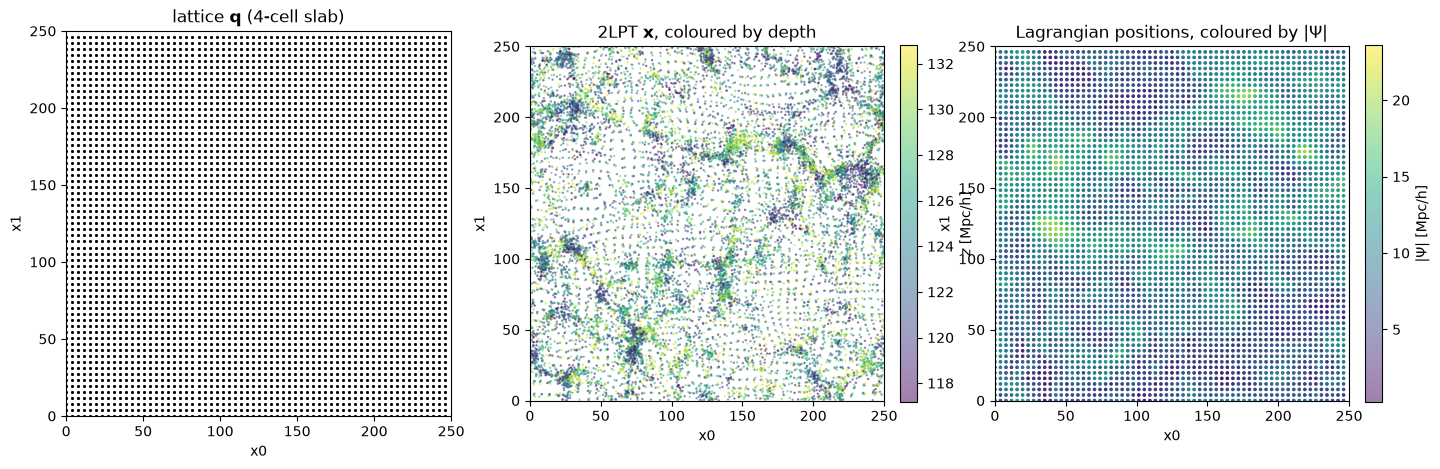

In [3]:
disp = np.asarray(jnp.linalg.norm(parts.displacement, axis=0))
fig, axs = plt.subplots(1, 3, figsize=(17, 5))
lattice.paint(ax=axs[0], axis=2, slab=(30, 34), s=1, c="k", title="lattice $\\mathbf{q}$ (4-cell slab)")
parts.paint(ax=axs[1], axis=2, slab=(30, 34), s=0.6, c="depth", colorbar=True, cbar_label="$z$ [Mpc/h]",
            title="2LPT $\\mathbf{x}$, coloured by depth")
parts.paint(ax=axs[2], coords="q", axis=2, slab=(30, 34), s=2, c=disp, cmap="viridis", colorbar=True,
            cbar_label="$|\\Psi|$ [Mpc/h]", title="Lagrangian positions, coloured by $|\\Psi|$");

## Mass-assignment schemes

Order $n$ B-splines: NGP (0), CIC (1), TSC (2), PCS (3). Each convolves the density with a window
$W(k) = \prod_i \mathrm{sinc}^{n+1}(k_i \Delta/2)$ and aliases power from above Nyquist.
Deconvolving the window restores the large-scale power; higher orders suppress aliasing.

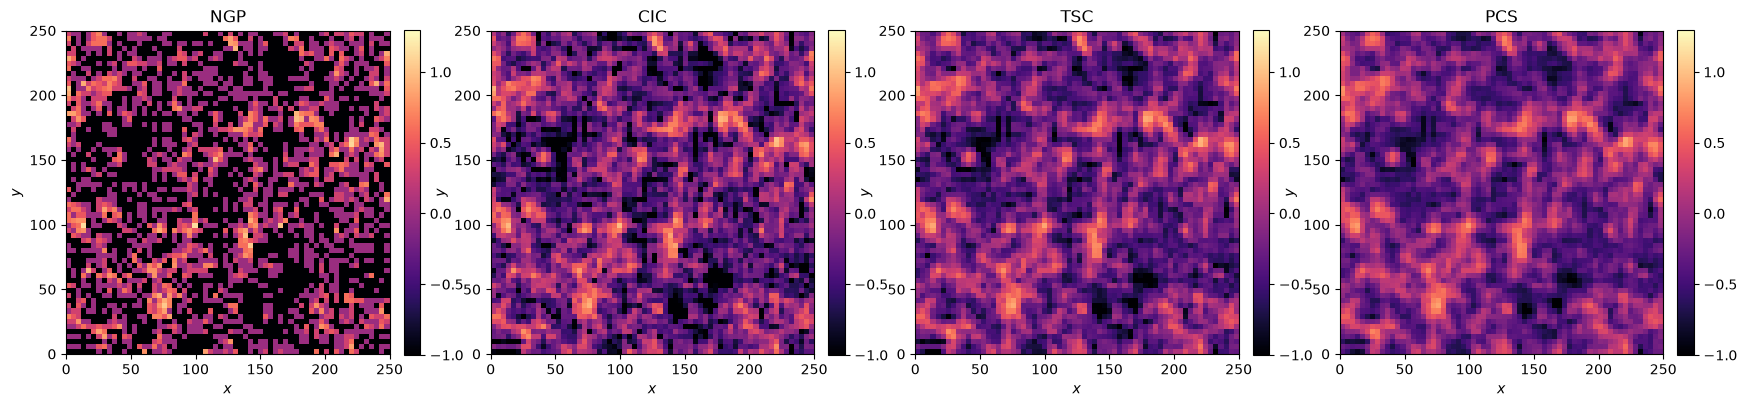

In [4]:
schemes = {0: "ngp", 1: "cic", 2: "tsc", 3: "pcs"}
dep = {n: parts.deposit(N, bspline_order=n, return_contrast=True) for n in schemes}
ref = stats.power_spectrum(parts.deposit(2 * N, bspline_order=3, bspline_scale="target_box", return_contrast=True)
                           .deconvolve(Window("pcs", L / (2 * N), normalized=True)), bins=bins)

fig, axs = plt.subplots(1, 4, figsize=(21, 4.6))
for ax, (n, name) in zip(axs, schemes.items()):
    (dep[n] + 1.0).paint(ax=ax, cmap="magma", log_data=True, vmin=-1, vmax=1.3, title=name.upper())

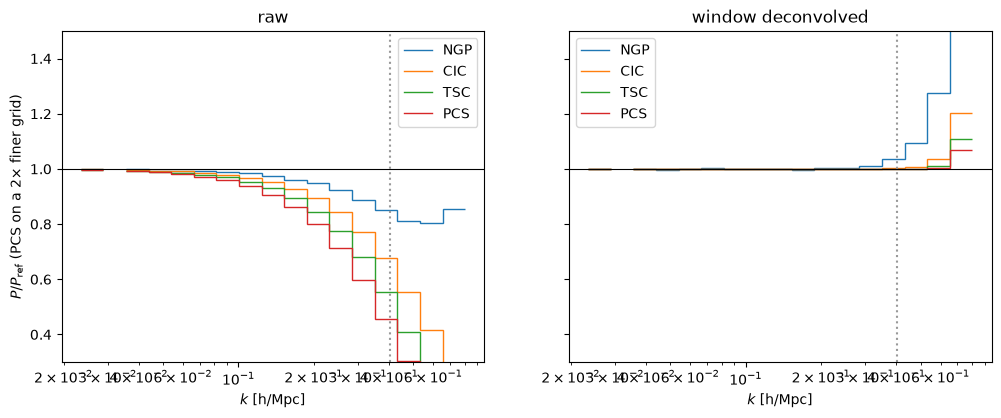

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.3), sharey=True)
for n, name in schemes.items():
    raw = stats.power_spectrum(dep[n], bins=bins)
    dc = stats.power_spectrum(dep[n].deconvolve(Window(name, box.R, normalized=True)), bins=bins)
    raw.plot(ax=axs[0], ratio_to=ref.values, label=name.upper())
    dc.plot(ax=axs[1], ratio_to=ref.values, label=name.upper())
for ax, title in zip(axs, ("raw", "window deconvolved")):
    ax.axhline(1, color="k", lw=0.8)
    ax.axvline(box.K_NYQ / 2, color="0.6", ls=":")
    ax.set(xlabel="$k$ [h/Mpc]", title=title, ylim=(0.3, 1.5))
    ax.legend()
axs[0].set_ylabel("$P / P_{\\rm ref}$ (PCS on a 2× finer grid)");

## Cloud size vs target grid

Depositing the $64^3$ particles on a finer $128^3$ grid: clouds sized to the particle spacing
(`bspline_scale="particles"`) keep the field smooth, clouds sized to the target cells resolve more
small-scale structure but also more discreteness noise.

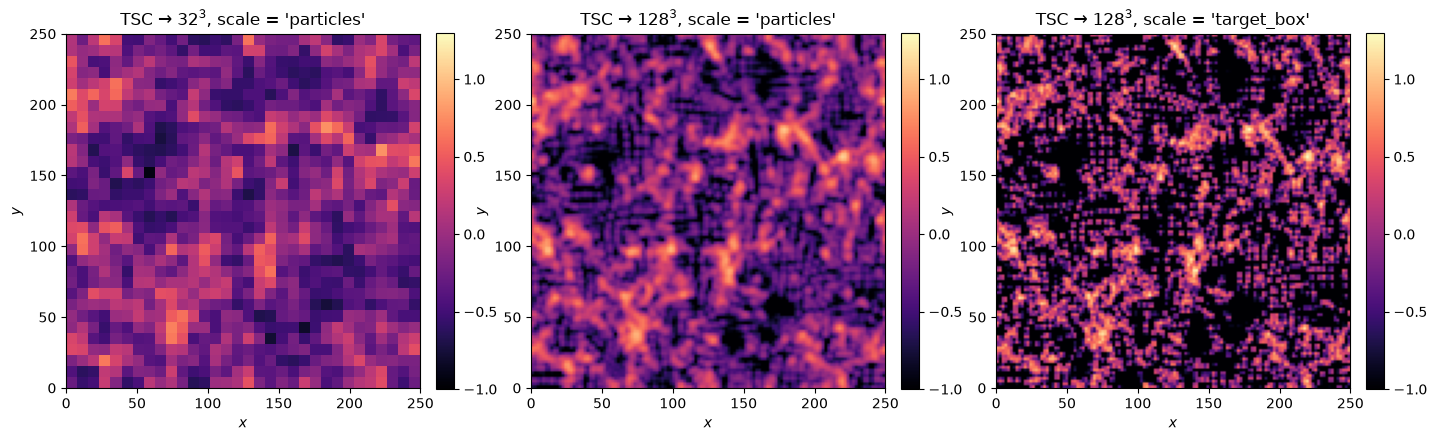

In [6]:
fig, axs = plt.subplots(1, 3, figsize=(17, 4.8))
opts = [(32, "particles"), (128, "particles"), (128, "target_box")]
for ax, (Nt, scale) in zip(axs, opts):
    (parts.deposit(Nt, bspline_order=2, bspline_scale=scale, return_contrast=True) + 1.0).paint(
        ax=ax, cmap="magma", log_data=True, vmin=-1, vmax=1.3, title=f"TSC → {Nt}$^3$, scale = '{scale}'")

## Interpolating fields at particle positions

`interpolate_at` supports trilinear and spectral (type-2 NUFFT) interpolation. The spectral interpolant is
exact for a band-limited field; e.g. at a half-cell offset the true values follow from the Fourier shift
theorem, and linear interpolation's error grows as the field gets rougher.

/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype complex128 requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/home/prosello/Documents/phd/code/cobox-repo/.venv/lib/python3.12/site-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


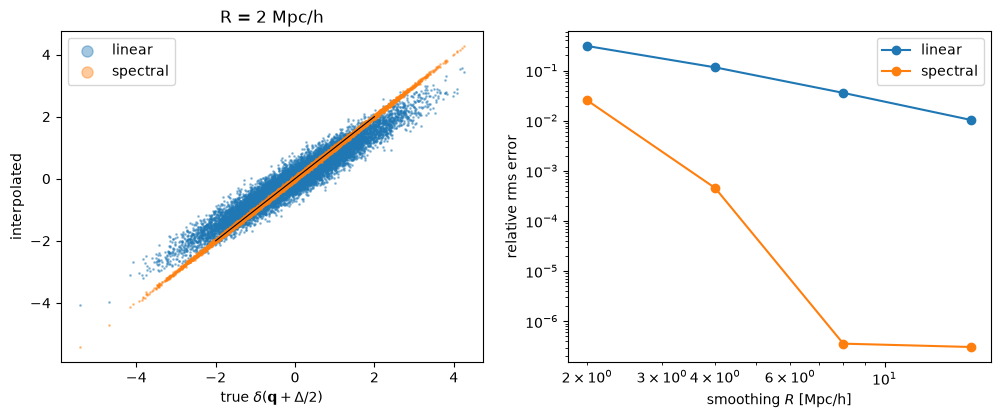

In [7]:
def shifted_truth(f, s):
    # f(x + s) via the shift theorem, s in Mpc/h per axis
    phase = jnp.exp(1j * sum(k * si for k, si in zip(box.k_axes, s)))
    return box.ifft(f.fft().data * phase)

s = jnp.array([0.5, 0.5, 0.5]) * box.R
positions = (Particles(box).q + s[:, None]) % L

fig, axs = plt.subplots(1, 2, figsize=(12, 4.3))
R_list = [2.0, 4.0, 8.0, 16.0]
errs = {"linear": [], "spectral": []}
for R in R_list:
    f = delta0.convolve(Window("gaussian", 2 * R, normalized=True))
    truth = shifted_truth(f, s).ravel()
    rms = float(jnp.std(truth))
    for method in errs:
        v = f.interpolate_at(positions, method=method)
        errs[method].append(float(jnp.sqrt(jnp.mean((v - truth) ** 2))) / rms)
    if R == 2.0:
        v_lin = f.interpolate_at(positions, method="linear")
        axs[0].scatter(truth[::20], v_lin[::20], s=1, alpha=0.4, label="linear")
        axs[0].scatter(truth[::20], f.interpolate_at(positions, method="spectral")[::20], s=1, alpha=0.4, label="spectral")
axs[0].plot([-2, 2], [-2, 2], "k", lw=0.8)
axs[0].set(xlabel="true $\\delta(\\mathbf{q} + \\Delta/2)$", ylabel="interpolated", title="R = 2 Mpc/h")
axs[0].legend(markerscale=8)
for method, e in errs.items():
    axs[1].loglog(R_list, e, "o-", label=method)
axs[1].set(xlabel="smoothing $R$ [Mpc/h]", ylabel="relative rms error")
axs[1].legend();